In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('healthcare_disease_prediction_dataset.csv')
df.head()

,Age,Gender,Blood Pressure,Cholesterol,Glucose,Smoking,Alcohol Consumption,Exercise,BMI,Family History,Heart Disease,Diabetes,Stroke,Kidney Disease,Cancer,Alzheimer's Disease,COPD,Liver Disease,Parkinson's Disease,Tuberculosis
0,69,Male,High,High,High,Yes,No,No,35.671099,No,1,0,0,0,1,0,0,0,0,0
1,32,Male,Low,High,Normal,Yes,No,Yes,38.554188,Yes,0,1,0,0,0,0,0,1,0,0
2,89,Female,Normal,High,Normal,No,No,Yes,18.932964,Yes,1,0,0,0,0,0,0,0,0,0
3,78,Male,High,High,High,No,No,Yes,21.806350,Yes,0,1,1,0,1,0,0,1,0,0
4,38,Male,Low,Normal,Normal,Yes,Yes,Yes,37.552683,No,0,0,0,0,0,0,0,0,0,0


# EDA

In [3]:
df.isna().sum()

Age                    0
Gender                 0
Blood Pressure         0
Cholesterol            0
Glucose                0
Smoking                0
Alcohol Consumption    0
Exercise               0
BMI                    0
Family History         0
Heart Disease          0
Diabetes               0
Stroke                 0
Kidney Disease         0
Cancer                 0
Alzheimer's Disease    0
COPD                   0
Liver Disease          0
Parkinson's Disease    0
Tuberculosis           0
dtype: int64

In [4]:
display(df.dtypes)

Age                      int64
Gender                     str
Blood Pressure             str
Cholesterol                str
Glucose                    str
Smoking                    str
Alcohol Consumption        str
Exercise                   str
BMI                    float64
Family History             str
Heart Disease            int64
Diabetes                 int64
Stroke                   int64
Kidney Disease           int64
Cancer                   int64
Alzheimer's Disease      int64
COPD                     int64
Liver Disease            int64
Parkinson's Disease      int64
Tuberculosis             int64
dtype: object

### Label Encoder

Text(0.5, 1.0, 'BMI distrubtion')

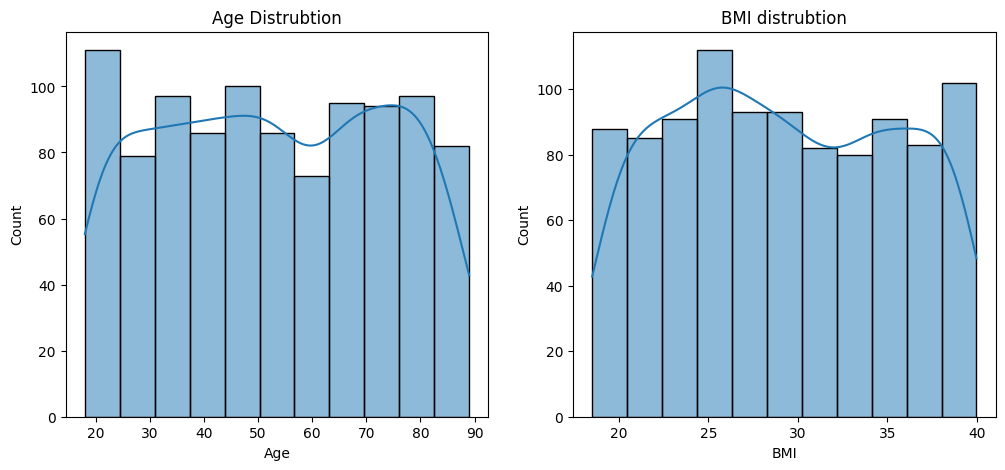

In [5]:
# Age and BMI Distribution

plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
sns.histplot(df['Age'], kde=True)
plt.title("Age Distrubtion")

plt.subplot(1, 2, 2)
sns.histplot(df['BMI'], kde=True)
plt.title("BMI distrubtion")

Text(0.5, 1.0, 'Distribution of Smokers in Dataset')

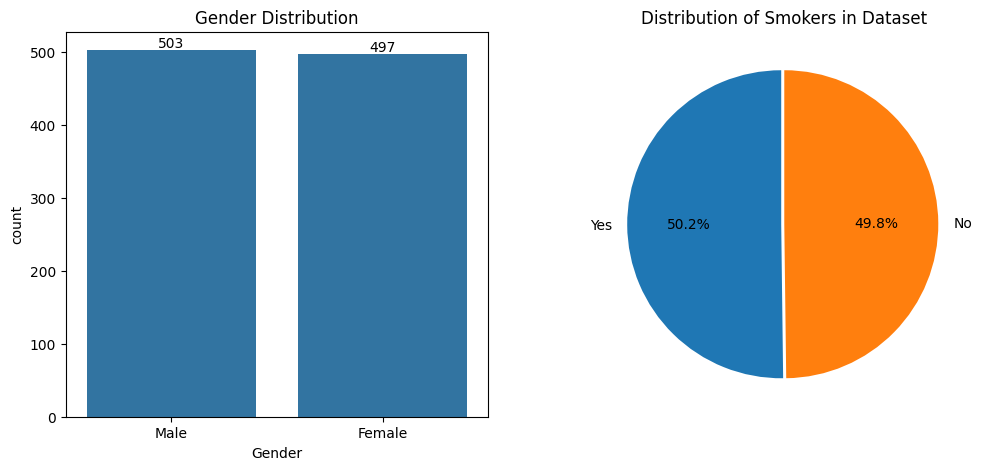

In [6]:
# Gender and Smokers Distribution

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
ax = sns.countplot(df, x='Gender')
ax.bar_label(ax.containers[0])
plt.title("Gender Distribution")

plt.subplot(1,2,2)
smoking_counts = df['Smoking'].value_counts()
plt.pie(smoking_counts, labels=smoking_counts.index, autopct='%1.1f%%', startangle=90, explode=(0.02, 0))
plt.title('Distribution of Smokers in Dataset')

Text(0.5, 0, 'Count')

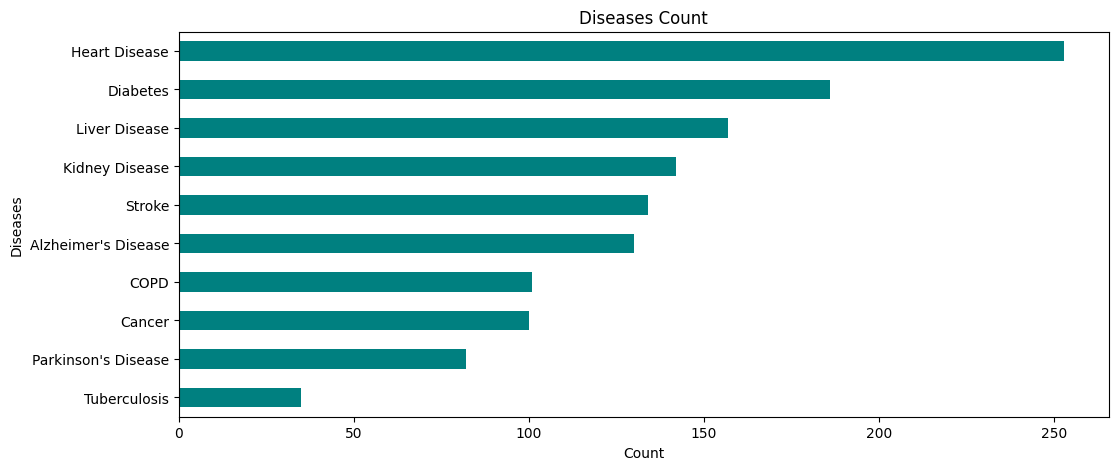

In [7]:
# Disease Count

diseases = ['Heart Disease', 'Diabetes', 'Stroke', 'Kidney Disease', 'Cancer', "Alzheimer's Disease", 'COPD', 'Liver Disease', "Parkinson's Disease", 'Tuberculosis']

plt.figure(figsize=(12,5))
df[diseases].sum().sort_values().plot(kind='barh', color="teal")
plt.title("Diseases Count")
plt.ylabel("Diseases")
plt.xlabel("Count")

In [8]:
le = LabelEncoder()

categorical_cols = ['Gender', 'Blood Pressure', 'Cholesterol', 'Glucose', 'Smoking', 'Alcohol Consumption', 'Exercise', 'Family History']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,Age,Gender,Blood Pressure,Cholesterol,Glucose,Smoking,Alcohol Consumption,Exercise,BMI,Family History,Heart Disease,Diabetes,Stroke,Kidney Disease,Cancer,Alzheimer's Disease,COPD,Liver Disease,Parkinson's Disease,Tuberculosis
0,69,1,0,0,0,1,0,0,35.671099,0,1,0,0,0,1,0,0,0,0,0
1,32,1,1,0,1,1,0,1,38.554188,1,0,1,0,0,0,0,0,1,0,0
2,89,0,2,0,1,0,0,1,18.932964,1,1,0,0,0,0,0,0,0,0,0
3,78,1,0,0,0,0,0,1,21.806350,1,0,1,1,0,1,0,0,1,0,0
4,38,1,1,1,1,1,1,1,37.552683,0,0,0,0,0,0,0,0,0,0,0


Text(0.5, 1.0, 'Correlation Heatmap')

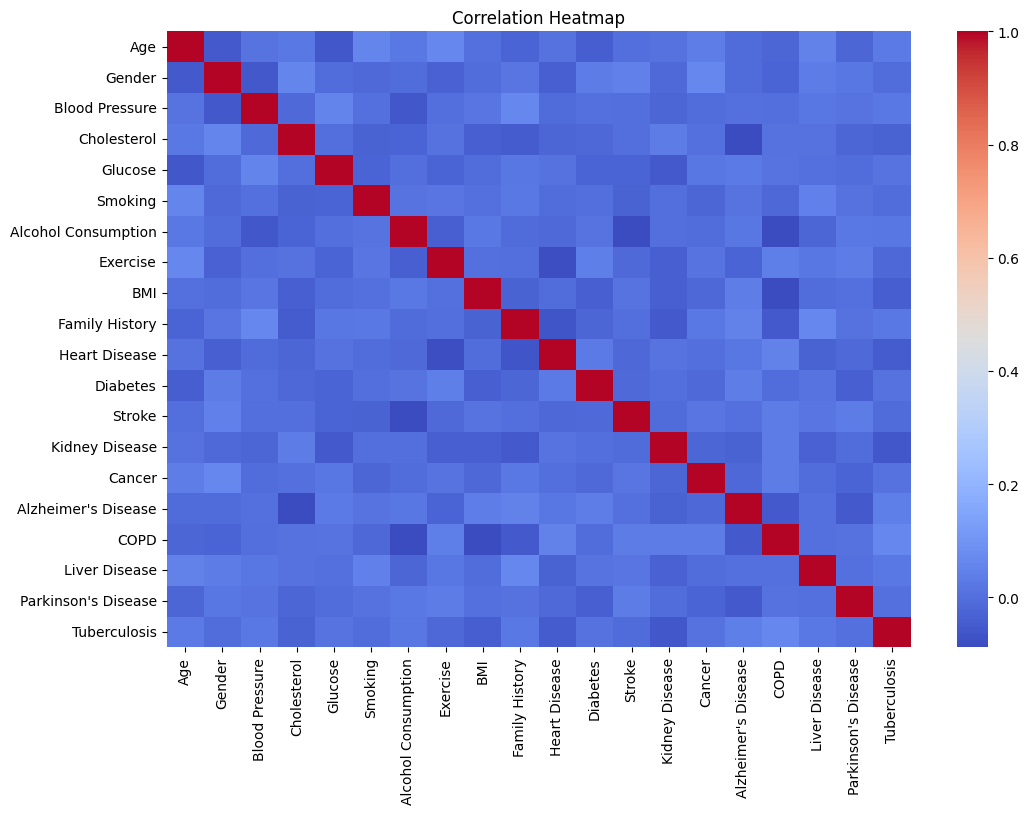

In [9]:
corr_matrix = df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap")

<Axes: xlabel='Smoking', ylabel='count'>

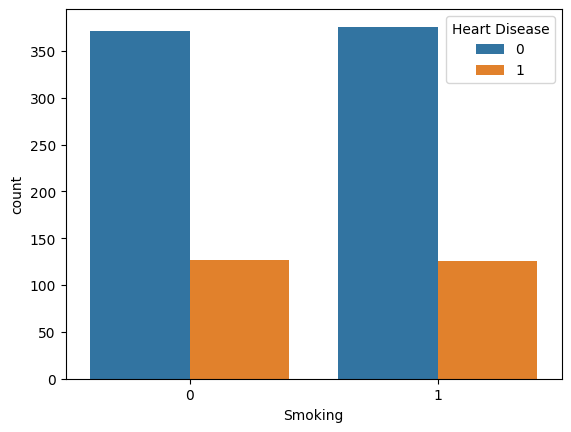

In [10]:
sns.countplot(x='Smoking', hue='Heart Disease', data=df)

<Axes: xlabel='Family History', ylabel='count'>

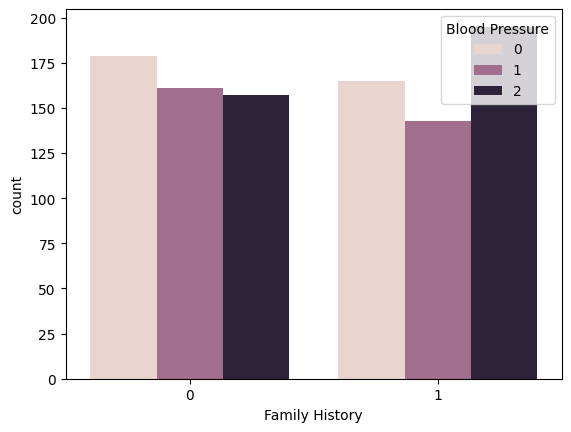

In [11]:
sns.countplot(x='Family History', hue='Blood Pressure', data=df)

# Split Train & Test

In [12]:
X = df.drop(columns=df[diseases])
Y = df[diseases]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print(f'Training set : {X_train.shape[0]} patients  ({X_train.shape[0]/len(df)*100:.0f}%)')
print(f'Testing set  : {X_test.shape[0]} patients  ({X_test.shape[0]/len(df)*100:.0f}%)')

Training set : 800 patients  (80%)
Testing set  : 200 patients  (20%)


# Random Forrest Classifier

In [13]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(class_weight='balanced')

model.fit(X_train, Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [14]:
from sklearn.metrics import accuracy_score, classification_report

Y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(Y_test, Y_pred))
print(classification_report(Y_test, Y_pred, zero_division=0))

Accuracy: 0.24
              precision    recall  f1-score   support

           0       0.33      0.03      0.06        58
           1       0.00      0.00      0.00        38
           2       1.00      0.06      0.12        16
           3       0.00      0.00      0.00        26
           4       0.00      0.00      0.00        23
           5       1.00      0.04      0.07        28
           6       0.00      0.00      0.00        16
           7       0.00      0.00      0.00        39
           8       0.00      0.00      0.00        17
           9       0.00      0.00      0.00         8

   micro avg       0.31      0.01      0.03       269
   macro avg       0.23      0.01      0.02       269
weighted avg       0.24      0.01      0.03       269
 samples avg       0.01      0.01      0.01       269



## Hyper parameter search

In [15]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='f1_weighted')
grid_search.fit(X_train, Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ht='balanced')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy', ...], 'max_depth': [None, 10, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for 

In [16]:
Y_pred = grid_search.predict(X_test)
print("Best parameters found: ", grid_search.best_params_)

print(classification_report(Y_test, Y_pred))

Best parameters found:  {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 10, 'n_estimators': 50}
              precision    recall  f1-score   support

           0       0.23      0.05      0.08        58
           1       0.25      0.05      0.09        38
           2       0.00      0.00      0.00        16
           3       0.50      0.08      0.13        26
           4       0.00      0.00      0.00        23
           5       0.00      0.00      0.00        28
           6       0.00      0.00      0.00        16
           7       0.33      0.03      0.05        39
           8       0.00      0.00      0.00        17
           9       0.00      0.00      0.00         8

   micro avg       0.20      0.03      0.05       269
   macro avg       0.13      0.02      0.04       269
weighted avg       0.18      0.03      0.05       269
 samples avg       0.04      0.02      0.03       269



/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  

## Change Threshold

In [17]:
# Get raw probability scores instead of 0 or 1, returns a list of arrays (one for each disease)
Y_probs_list = grid_search.predict_proba(X_test)
Y_probs = np.transpose([p[:, 1] for p in Y_probs_list])

threshold = 0.2

# Convert probabilities to 0 or 1 based on your threshold
Y_pred_thresholded = (Y_probs >= threshold).astype(int)

print(f"--- Classification Report (Threshold: {threshold}) ---")
print(classification_report(Y_test, Y_pred_thresholded, target_names=diseases, zero_division=0))

--- Classification Report (Threshold: 0.2) ---
                     precision    recall  f1-score   support

      Heart Disease       0.30      0.93      0.45        58
           Diabetes       0.20      0.92      0.32        38
             Stroke       0.07      0.69      0.13        16
     Kidney Disease       0.11      0.54      0.18        26
             Cancer       0.08      0.35      0.13        23
Alzheimer's Disease       0.14      0.64      0.23        28
               COPD       0.07      0.56      0.13        16
      Liver Disease       0.19      0.69      0.29        39
Parkinson's Disease       0.06      0.29      0.10        17
       Tuberculosis       0.04      0.12      0.06         8

          micro avg       0.15      0.68      0.24       269
          macro avg       0.12      0.57      0.20       269
       weighted avg       0.16      0.68      0.26       269
        samples avg       0.15      0.49      0.22       269



# XGBoost Clasifier

In [18]:
from xgboost import XGBClassifier
from sklearn.multioutput import MultiOutputClassifier

xgb_base = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    scale_pos_weight=5,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Wrap it for Multi-label
multi_xgb = MultiOutputClassifier(xgb_base)

## Do Hyper Parameter Search

In [19]:
param_grid_xgb = {
    'estimator__n_estimators': [100, 200],
    'estimator__max_depth': [3, 5, 7],
    'estimator__learning_rate': [0.01, 0.1],
    'estimator__gamma': [0, 0.1]
}

In [20]:
grid_xgb = GridSearchCV(
    estimator=multi_xgb, 
    param_grid=param_grid_xgb, 
    cv=3, 
    scoring='f1_weighted', 
    n_jobs=-1
)

grid_xgb.fit(X_train, Y_train)
print("Best parameters:", grid_xgb.best_params_)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [11:33:48] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [11:33:48] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [11:33:48] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [11:33:48] WARN

Best parameters: {'estimator__gamma': 0, 'estimator__learning_rate': 0.01, 'estimator__max_depth': 3, 'estimator__n_estimators': 200}


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [11:33:51] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [21]:
# Get probabilities
Y_probs_list = grid_xgb.predict_proba(X_test)
Y_probs = np.transpose([p[:, 1] for p in Y_probs_list])

# Set a sensitive threshold
threshold = 0.4
Y_pred_xgb = (Y_probs >= threshold).astype(int)

print(classification_report(Y_test, Y_pred_xgb, target_names=diseases, zero_division=0))

                     precision    recall  f1-score   support

      Heart Disease       0.29      0.95      0.45        58
           Diabetes       0.19      0.97      0.32        38
             Stroke       0.09      0.88      0.16        16
     Kidney Disease       0.12      0.77      0.21        26
             Cancer       0.08      0.13      0.10        23
Alzheimer's Disease       0.17      0.64      0.26        28
               COPD       0.06      0.19      0.09        16
      Liver Disease       0.18      0.72      0.29        39
Parkinson's Disease       0.20      0.12      0.15        17
       Tuberculosis       0.00      0.00      0.00         8

          micro avg       0.17      0.67      0.27       269
          macro avg       0.14      0.54      0.20       269
       weighted avg       0.17      0.67      0.26       269
        samples avg       0.17      0.50      0.24       269

